# Review

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config / reproducibility
RNG = np.random.default_rng(2026)
n_cities = 10
days_per_year = 365
n_years = 1
n_rows = n_cities * days_per_year * n_years

# City identifiers
cities = [f"city_{i+1}" for i in range(n_cities)]

# Per-city static attributes (population and number of hospitals)
# Populations: sample from a realistic urban range, ensure integer and larger than typical admissions
city_pops = RNG.integers(low=50_000, high=1_000_000, size=n_cities)
# Number of hospitals: small integers
city_hospitals = RNG.integers(low=1, high=10, size=n_cities)

city_info = pd.DataFrame({
    "city": cities,
    "population": city_pops,
    "n_hospitals": city_hospitals
})

# Pollution types: let's create 4 pollutant columns (e.g., PM2.5, NO2, O3, SO2)
pollutants = ["pm25", "no2", "o3", "so2"]
n_pollutants = len(pollutants)

# For each city and pollutant, choose a city-specific mean and std dev for Gaussian sampling
pollution_means = RNG.normal(loc=25.0, scale=10.0, size=(n_cities, n_pollutants))
pollution_stds = np.abs(RNG.normal(loc=5.0, scale=2.0, size=(n_cities, n_pollutants)))
# Ensure stds are positive and not too small
pollution_stds = np.clip(pollution_stds, 1e-2, None)

# Choose which pollutant is causally linked to hospital admissions
causal_idx = RNG.integers(0, n_pollutants)  # index into pollutants
causal_pollutant = pollutants[causal_idx]

# Linear relationship parameters for admissions: admissions ≈ alpha * pollutant + intercept + noise
alpha = RNG.uniform(0.05, 0.5)   # slope (per pollutant unit)
print("alpha = ", alpha)
intercept = RNG.integers(0, 5)   # small baseline
admission_noise_sd_scale = RNG.uniform(5.0, 15.0)  # noise scale factor

# Build rows
rows = []
for city_idx, city in enumerate(cities):
    pop = int(city_pops[city_idx])
    n_hosp = int(city_hospitals[city_idx])
    for day in range(days_per_year * n_years):
        # Sample pollutant values for this city/day
        pollutant_vals = RNG.normal(loc=pollution_means[city_idx],
                                    scale=pollution_stds[city_idx])
        # Temperature (independent random Gaussian; no seasonality required)
        temp = RNG.normal(loc=60.0, scale=15.0)  # Fahrenheit-like values
        
        # Hospital admissions: linear in the causal pollutant for this city + noise
        causal_value = pollutant_vals[causal_idx]
        # Set noise SD proportional to typical pollutant std to make signal detectable but noisy
        noise_sd = admission_noise_sd_scale * (np.mean(pollution_stds[city_idx]) / 5.0)
        admissions_cont = intercept + alpha * causal_value + RNG.normal(0, noise_sd)
        # Admissions must be non-negative and integer, and less than population
        admissions = int(max(0, np.round(admissions_cont)))
        # Ensure admissions are smaller than population (enforce by capping)
        admissions = min(admissions, pop - 1)
        
        row = {
            "city": city,
            "day_of_year": day + 1,
            "population": pop,
            "n_hospitals": n_hosp,
            "temperature": temp,
            "admissions": admissions
        }
        for i, pol in enumerate(pollutants):
            row[pol] = float(pollutant_vals[i])
        rows.append(row)

df = pd.DataFrame(rows)

# Basic sanity checks / prints (can be commented out if not desired)
assert df.shape[0] == n_rows
# Each city should have constant population and hospital count across days
for city in cities:
    subset = df[df["city"] == city]
    assert subset["population"].nunique() == 1
    assert subset["n_hospitals"].nunique() == 1
    # Admissions less than population
    assert (subset["admissions"] < subset["population"]).all()

# Quick correlation check (not part of the dataset, just informative)
# Uncomment if you want to see which pollutant correlates with admissions
# print(df[pollutants + ["admissions"]].corr()["admissions"].sort_values(ascending=False))

# Expose causal pollutant info for downstream use
df.attrs["causal_pollutant"] = causal_pollutant
df.attrs["causal_alpha"] = alpha
df.attrs["causal_intercept"] = intercept

# Save or return the dataframe (here we simply show first rows)
print(f"Generated {df.shape[0]} rows for {n_cities} cities.")
print(df.head())

# If desired, save to CSV:
# df.to_csv("synthetic_city_pollution_admissions.csv", index=False)

alpha =  0.15496844279006244
Generated 3650 rows for 10 cities.
     city  day_of_year  population  n_hospitals  temperature  admissions  \
0  city_1            1      859259            8    63.759758           0   
1  city_1            2      859259            8    54.649285          28   
2  city_1            3      859259            8    77.217096           0   
3  city_1            4      859259            8    84.964500           0   
4  city_1            5      859259            8    53.124566           0   

        pm25        no2         o3        so2  
0  21.644664  30.927322  31.825254  21.472956  
1  23.578070  17.123241  24.254630  30.765305  
2  33.830374  29.904756  26.258261  27.551502  
3  13.354415  30.910601  22.112432  23.955294  
4  38.500181  36.441056  26.050708  31.962456  


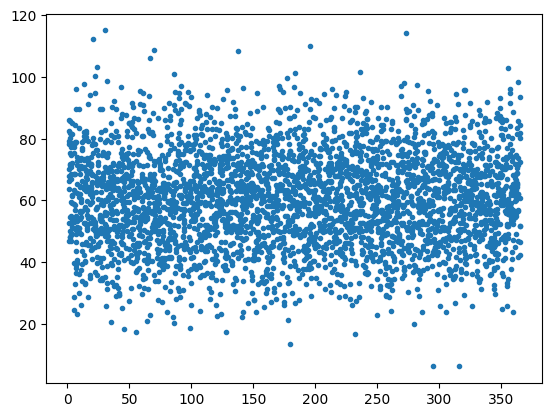

In [16]:
plt.plot(df["day_of_year"], df["temperature"], ".")

In [17]:
df.groupby("city").mean()[["pm25", "no2", "o3", "so2", "admissions"]].corr()

,pm25,no2,o3,so2,admissions
pm25,1.000000,-0.577019,0.575632,0.471503,0.729434
no2,-0.577019,1.000000,-0.188477,-0.443720,-0.320201
o3,0.575632,-0.188477,1.000000,0.801361,0.929369
so2,0.471503,-0.443720,0.801361,1.000000,0.840419
admissions,0.729434,-0.320201,0.929369,0.840419,1.000000


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

Mean (E[X]) = 10.456712328767123
Median = 10.0
Mode = 0


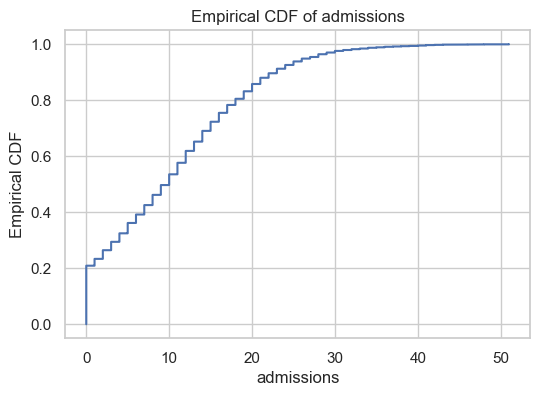

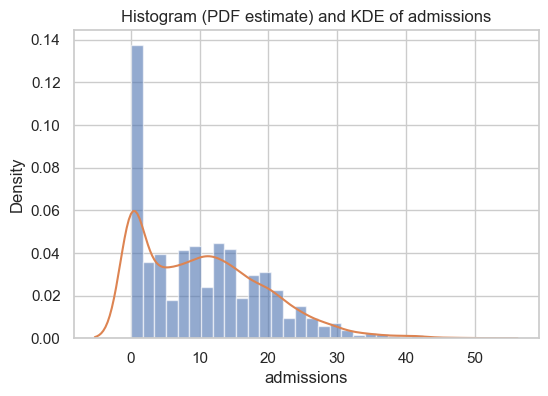

In [19]:
# Choose a numeric column, e.g., admissions
col = "admissions"
series = df[col]

mean_val = series.mean()            # expected value (sample)
median_val = series.median()
mode_val = series.mode().iloc[0] if not series.mode().empty else np.nan

print("Mean (E[X]) =", mean_val)
print("Median =", median_val)
print("Mode =", mode_val)

# Empirical CDF (use statsmodels or manual)
x_sorted = np.sort(series.values)
cdf_vals = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure(figsize=(6, 4))
plt.step(x_sorted, cdf_vals, where="post")
plt.xlabel(col)
plt.ylabel("Empirical CDF")
plt.title(f"Empirical CDF of {col}")
plt.show()

# Estimated PDF (histogram) for continuous-like variables
plt.figure(figsize=(6, 4))
plt.hist(series, bins=30, density=True, alpha=0.6)
# Overlay a kernel density estimate (smoothed PDF)
sns.kdeplot(series, bw_adjust=1.0)
plt.title(f"Histogram (PDF estimate) and KDE of {col}")
plt.show()

In [20]:
sd = series.std(ddof=1)   # sample standard deviation
var = series.var(ddof=1)  # sample variance

print("Std dev =", sd)
print("Variance =", var)

# L2 norm of centered data (sqrt of sum of squared deviations)
centered = series - mean_val
l2_norm = np.linalg.norm(centered)   # sqrt(sum((x - mean)^2))
print("L2 norm of centered vector =", l2_norm)

# Covariance between admissions and the causal pollutant
causal = df.attrs.get("causal_pollutant", "pm25")
cov = np.cov(df[causal], df["admissions"], ddof=1)[0, 1]
print(f"Cov({causal}, admissions) =", cov)

Std dev = 9.040387146936592
Variance = 81.72859976649634
L2 norm of centered vector = 546.1022436759846
Cov(so2, admissions) = 13.794676830400867


In [21]:
# Stddev = sqrt(sum((x - mean)**2)/num)
# L2 norm = sqrt(sum((x - mean)**2)
np.sqrt(3649) * 9.0403871469

546.1022436737749

In [22]:
# Sample quantiles
quantiles = series.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("Quantiles:\n", quantiles)

# Inverse CDF example: find p such that value <= q
# Series.quantile is the empirical inverse CDF
q50 = series.quantile(0.5)
print("Median via inverse CDF:", q50)

# Order statistics: smallest and largest few values
k = 5
smallest_k = series.nsmallest(k)
largest_k = series.nlargest(k)
print("Smallest k:", smallest_k.values)
print("Largest k:", largest_k.values)

Quantiles:
 0.01     0.0
0.05     0.0
0.25     2.0
0.50    10.0
0.75    16.0
0.95    27.0
0.99    36.0
Name: admissions, dtype: float64
Median via inverse CDF: 10.0
Smallest k: [0 0 0 0 0]
Largest k: [51 48 47 46 45]


In [25]:
sorted(series)[-36:]

[36,
 36,
 36,
 37,
 37,
 37,
 37,
 38,
 38,
 38,
 38,
 39,
 39,
 39,
 40,
 40,
 40,
 40,
 40,
 41,
 41,
 41,
 41,
 41,
 41,
 42,
 42,
 42,
 43,
 43,
 43,
 45,
 46,
 47,
 48,
 51]

In [8]:
rng = series.max() - series.min()
print("Range:", rng)
print("Min:", series.min(), "Max:", series.max())

Range: 51
Min: 0 Max: 51


In [13]:
np.around(len(series)/100)

36.0

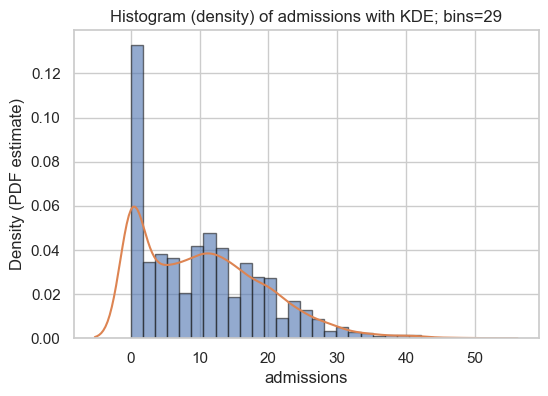

In [15]:
plt.figure(figsize=(6, 4))
# Use Freedman–Diaconis rule for bin width (optional)
iqr = series.quantile(0.75) - series.quantile(0.25)
n = len(series)
bin_width = 2 * iqr * n ** (-1/3) if iqr > 0 else 1.0
bins = max(5, int(np.ceil((series.max() - series.min()) / bin_width)))

plt.hist(series, bins=bins, density=True, alpha=0.6, color="C0", edgecolor="k")
sns.kdeplot(series, bw_adjust=1.0, color="C1")
plt.title(f"Histogram (density) of {col} with KDE; bins={bins}")
plt.xlabel(col)
plt.ylabel("Density (PDF estimate)")
plt.show()

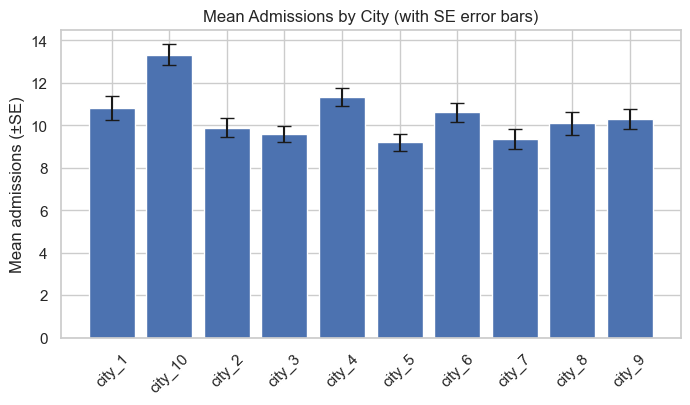

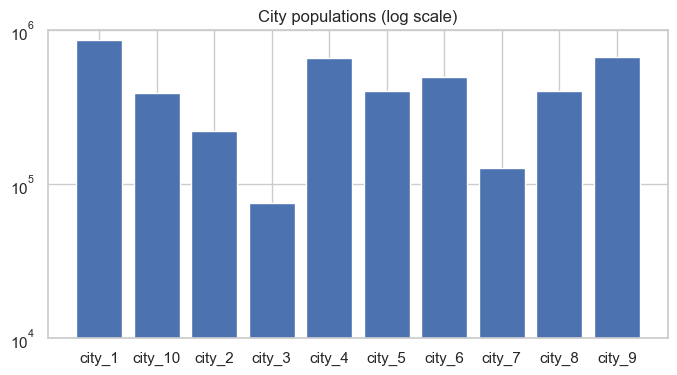

In [79]:
# Example: mean admissions by city (nominal categorical axis)
group = df.groupby("city")["admissions"]
means = group.mean()
stds = group.std(ddof=1)
counts = group.count()

# Using matplotlib
plt.figure(figsize=(8, 4))
x = np.arange(len(means))
plt.bar(x, means, yerr=stds / np.sqrt(counts), capsize=5)  # errorbars = SE
plt.xticks(x, means.index, rotation=45)
plt.ylabel("Mean admissions (±SE)")
plt.title("Mean Admissions by City (with SE error bars)")
plt.show()

# Log vs linear y-axis example: show population (large differences)
pop_by_city = df.groupby("city")["population"].first()
plt.figure(figsize=(8, 4))
plt.bar(pop_by_city.index, pop_by_city.values)
plt.yscale("log")  # change to 'linear' to compare
ax = plt.gca()
ax.set_yticks([1e4, 1e5, 1e6])
plt.title("City populations (log scale)")
plt.show()

In [29]:
df.groupby("city").mean()["so2"].std()*alpha, df.groupby("city").mean()["admissions"].std()

(1.7578489167351925, 1.2097806550509136)

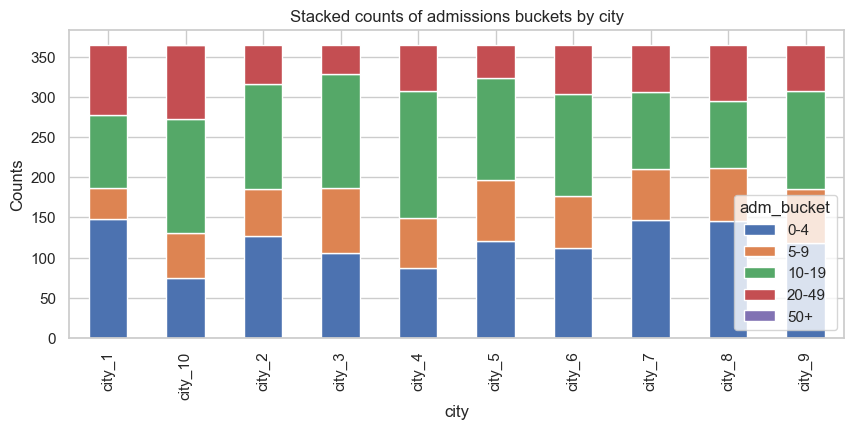

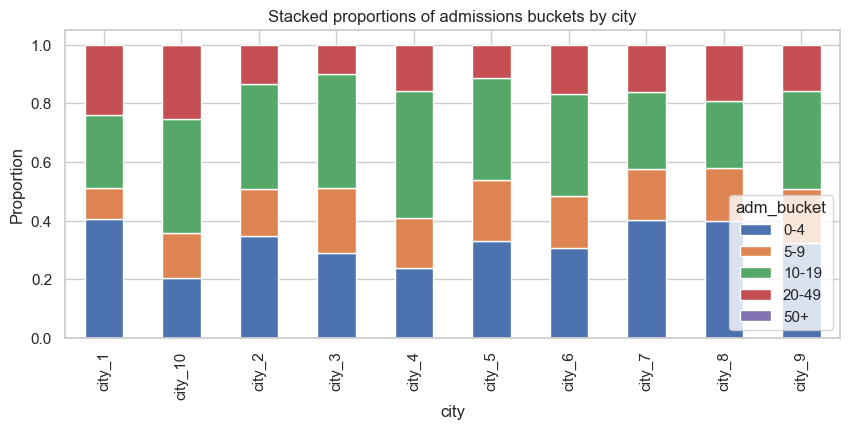

In [31]:
# Example: categorize admissions into buckets, then stacked counts by city
bins = [0, 5, 10, 20, 50, df["admissions"].max() + 1]
#bins = [0, 10, 20, 30, 40, df["admissions"].max() + 1]
labels = ["0-4", "5-9", "10-19", "20-49", "50+"]
#labels = ["0-9", "10-19", "20-30", "30-39", "40+"]
df["adm_bucket"] = pd.cut(df["admissions"], bins=bins, labels=labels, right=False)

stack_counts = df.pivot_table(index="city", columns="adm_bucket", aggfunc="size", fill_value=0)
# Stacked counts
stack_counts.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Stacked counts of admissions buckets by city")
plt.ylabel("Counts")
plt.show()

# Stacked proportions
stack_prop = stack_counts.divide(stack_counts.sum(axis=1), axis=0)
stack_prop.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Stacked proportions of admissions buckets by city")
plt.ylabel("Proportion")
plt.show()

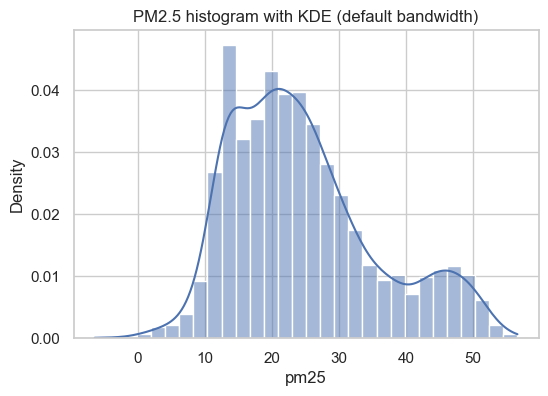

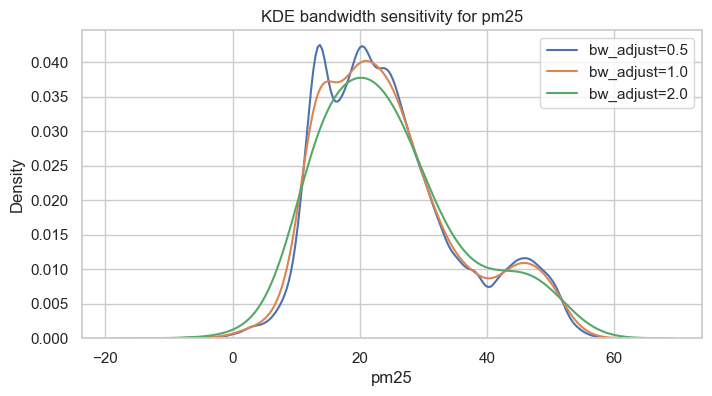

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df["pm25"], kde=True, stat="density", bins=30)
plt.title("PM2.5 histogram with KDE (default bandwidth)")
plt.show()

# Bandwidth tuning example
plt.figure(figsize=(8, 4))
for bw_factor in [0.5, 1.0, 2.0]:
    sns.kdeplot(df["pm25"], bw_adjust=bw_factor, label=f"bw_adjust={bw_factor}")
plt.title("KDE bandwidth sensitivity for pm25")
plt.legend()
plt.show()

/Users/joshuavk2/Library/Python/3.12/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/joshuavk2/Library/Python/3.12/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/joshuavk2/Library/Python/3.12/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/joshuavk2/Library/Python/3.12/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 16.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/joshuavk2/Library/Pytho

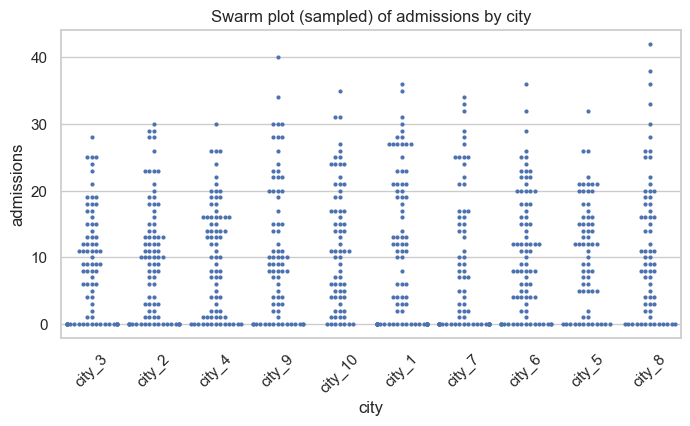

In [19]:
plt.figure(figsize=(8, 4))
# sample to avoid extreme overplotting
sample = df.sample(frac=0.2, random_state=1)
sns.swarmplot(x="city", y="admissions", data=sample, size=3)
plt.title("Swarm plot (sampled) of admissions by city")
plt.xticks(rotation=45)
plt.show()

In [88]:
#sample.groupby("city").so2.mean(), sample.groupby("city").admissions.std()

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_25050/863864604.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(x="city", y="admissions", data=df, inner="quartile", scale="area")


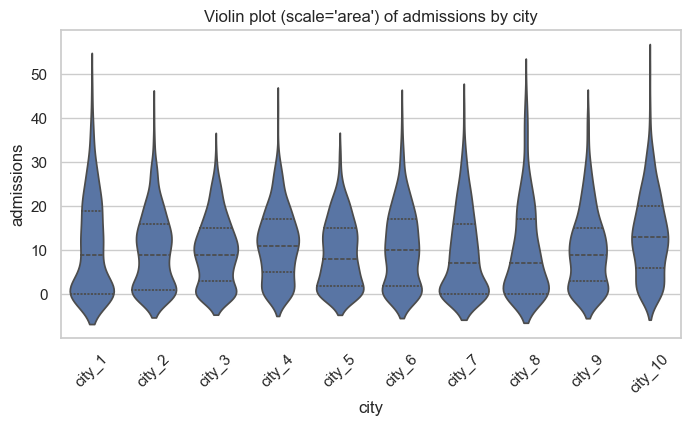

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_25050/863864604.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="city", y="admissions", data=df, inner="quartile", scale="width")


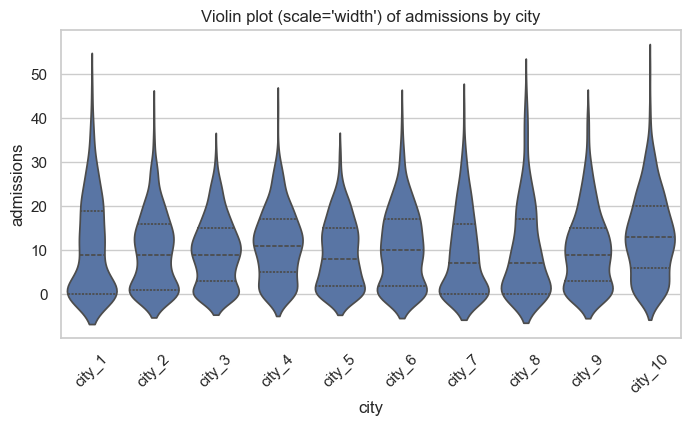

In [20]:
plt.figure(figsize=(8, 4))
# default: violin area scaled to number of observations per category
sns.violinplot(x="city", y="admissions", data=df, inner="quartile", scale="area")
plt.title("Violin plot (scale='area') of admissions by city")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 4))
sns.violinplot(x="city", y="admissions", data=df, inner="quartile", scale="width")
plt.title("Violin plot (scale='width') of admissions by city")
plt.xticks(rotation=45)
plt.show()

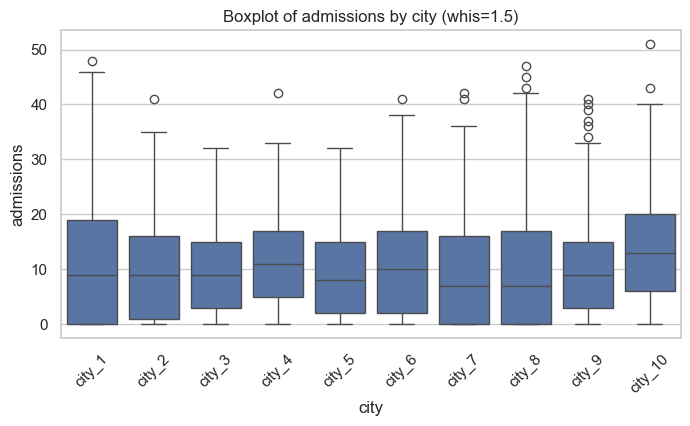

Five-number summary for city: {'min': 0, 'Q1': 0.0, 'median': 9.0, 'Q3': 19.0, 'max': 48}


In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="city", y="admissions", data=df, whis=1.5)  # default whisker rule: 1.5*IQR
plt.title("Boxplot of admissions by city (whis=1.5)")
plt.xticks(rotation=45)
plt.show()

# Show the underlying five-number summary for one city
city0 = df[df["city"] == df["city"].unique()[0]]["admissions"]
five_num = {
    "min": city0.min(),
    "Q1": city0.quantile(0.25),
    "median": city0.median(),
    "Q3": city0.quantile(0.75),
    "max": city0.max()
}
print("Five-number summary for city:", five_num)

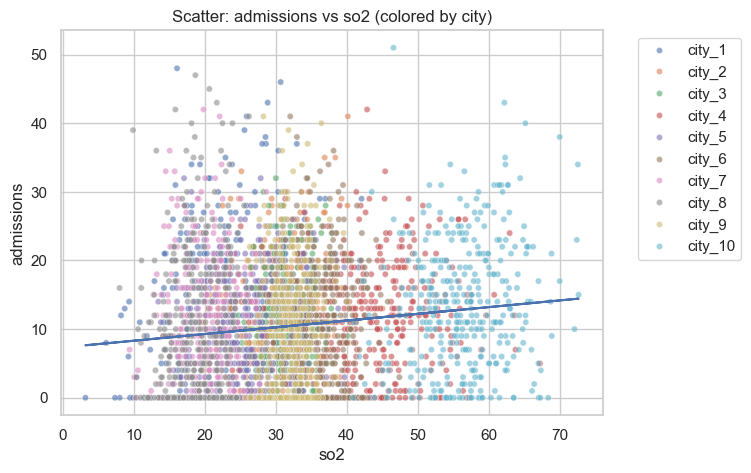

In [36]:
causal = df.attrs.get("causal_pollutant", "pm25")
plt.figure(figsize=(7, 5))
sns.scatterplot(x=causal, y="admissions", hue="city", data=df, alpha=0.6, s=20)
plt.title(f"Scatter: admissions vs {causal} (colored by city)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(df[[causal]], df["admissions"])
plt.plot(df[[causal]], reg.predict(df[[causal]]))
plt.show()

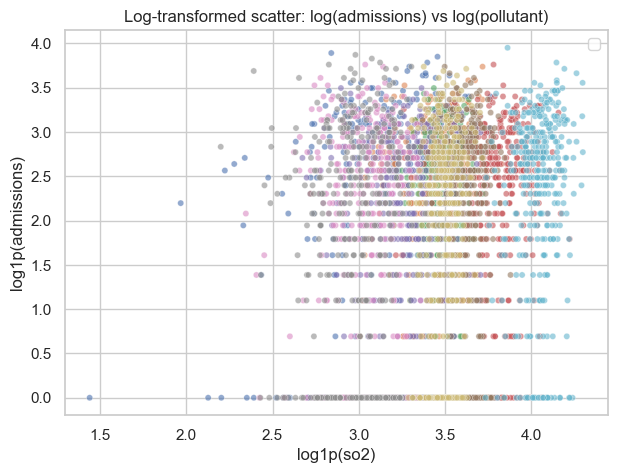

In [35]:
# Add small constant to avoid log(0)
eps = 1e-6
plt.figure(figsize=(7, 5))
sns.scatterplot(x=np.log1p(df[causal] + eps), y=np.log1p(df["admissions"] + eps), hue="city", data=df, alpha=0.6, s=20)
plt.xlabel(f"log1p({causal})")
plt.ylabel("log1p(admissions)")
plt.title("Log-transformed scatter: log(admissions) vs log(pollutant)")
plt.legend([],[])  # hide legend to reduce clutter, or keep if desired
plt.show()

In [35]:
np.log1p(0), np.log(1 + 0), np.log(0), np.log1p(1)

/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_43608/3661339081.py:1: RuntimeWarning: divide by zero encountered in log
  np.log1p(0), np.log(1 + 0), np.log(0), np.log1p(1)


(0.0, 0.0, -inf, 0.6931471805599453)

In [37]:
causal = df.attrs.get("causal_pollutant")
print("Causal:", causal)
print("Corr admissions vs o3:", df["admissions"].corr(df["o3"]))
print("Corr admissions vs causal pollutant:", df["admissions"].corr(df[causal]))

# City-level means to see between-city shifts
city_means = df.groupby("city")[[ "admissions", "o3", causal ]].mean()
print(city_means.sort_values("admissions"))

Causal: so2
Corr admissions vs o3: 0.11508813534645815
Corr admissions vs causal pollutant: 0.12854831224319824
         admissions         o3        so2
city                                     
city_5     9.208219  12.578580  26.400679
city_7     9.358904  19.413444  20.113472
city_3     9.597260  20.322121  31.669810
city_2     9.890411  21.026178  30.528686
city_8    10.098630  27.237621  18.949617
city_9    10.301370  31.253818  32.147105
city_6    10.610959  33.782362  36.276735
city_1    10.830137  24.157380  23.799060
city_4    11.342466  31.320325  43.164036
city_10   13.328767  50.622776  56.548173


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[[causal]].values
y = df["admissions"].values
model = LinearRegression().fit(X, y)
print("coef, intercept:", model.coef_[0], model.intercept_)
print("R^2 (causal):", r2_score(y, model.predict(X)))

# Compare to so2
model_so2 = LinearRegression().fit(df[["so2"]].values, y)
print("coef_so2, intercept:", model_so2.coef_[0], model_so2.intercept_)
print("R^2 (so2):", r2_score(y, model_so2.predict(df[["so2"]].values)))

coef, intercept: 0.09790283899362257 7.32776331494385
R^2 (causal): 0.016524668580574664
coef_so2, intercept: 0.09790283899362257 7.32776331494385
R^2 (so2): 0.016524668580574664


<Axes: xlabel='so2', ylabel='admissions'>

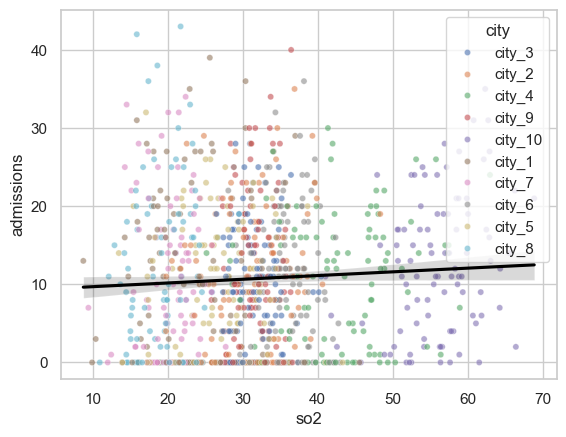

In [38]:
sample = df.sample(n=1000, random_state=1)
sns.scatterplot(x="so2", y="admissions", hue="city", data=sample, alpha=0.6, s=20)
sns.regplot(x="so2", y="admissions", data=sample, scatter=False, color="black", lowess=False)

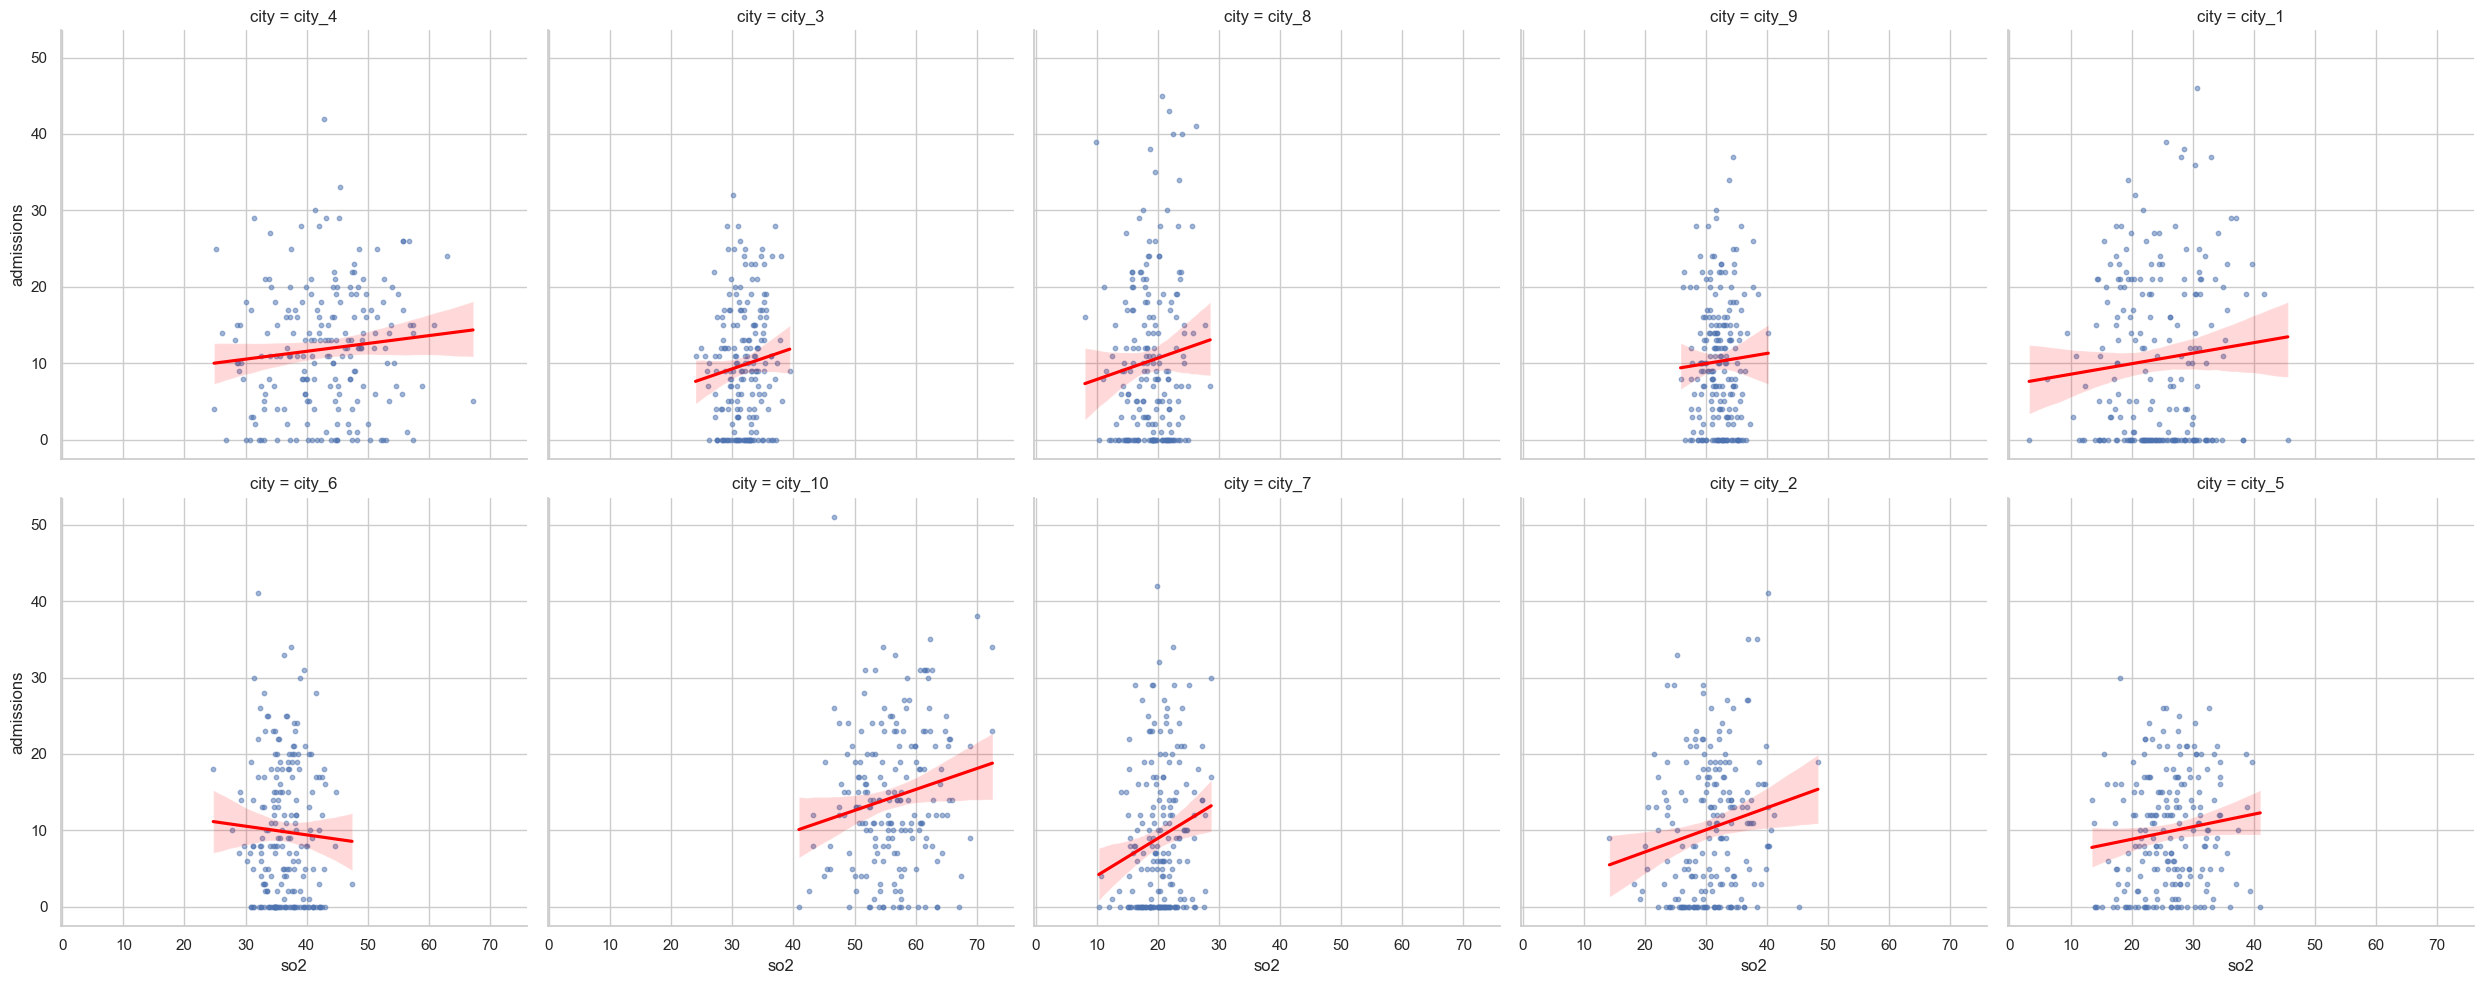

In [39]:
sns.lmplot(x="so2", y="admissions", col="city", col_wrap=5, data=df.sample(n=2000, random_state=2),
           scatter_kws={"s":10, "alpha":0.5}, line_kws={"color":"red"})

<Axes: xlabel='so2', ylabel='admissions'>

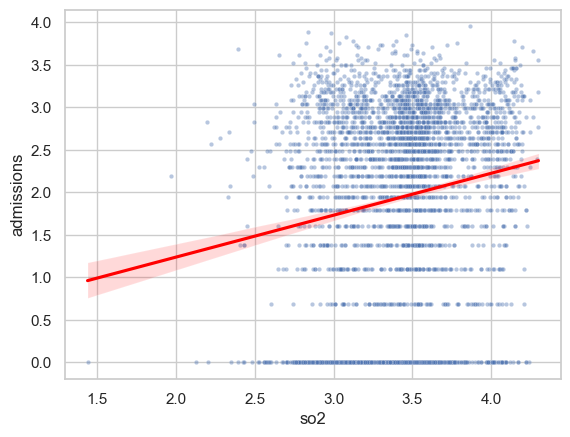

In [40]:
sns.scatterplot(x=np.log1p(df["so2"]), y=np.log1p(df["admissions"]), alpha=0.4, s=10)
sns.regplot(x=np.log1p(df["so2"]), y=np.log1p(df["admissions"]), scatter=False, color="red")

In [41]:
import statsmodels.api as sm
X = sm.add_constant(df[causal])
res = sm.OLS(df["admissions"], X).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:             admissions   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     61.29
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.39e-15
Time:                        18:04:53   Log-Likelihood:                -13184.
No. Observations:                3650   AIC:                         2.637e+04
Df Residuals:                    3648   BIC:                         2.639e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3278      0.426     17.188      0.0

In [42]:
print(df.attrs.get("causal_pollutant"), df.attrs.get("causal_alpha"), df.attrs.get("causal_intercept"))

so2 0.15496844279006244 4


In [43]:
# Which pollutant is causal?
print("causal:", df.attrs.get("causal_pollutant"))

# Correlations
for pol in ["pm25","no2","o3","so2"]:
    print(pol, "corr with admissions:", df["admissions"].corr(df[pol]))

# Fit linear model on causal pollutant
from sklearn.linear_model import LinearRegression
X = df[[df.attrs.get("causal_pollutant")]].values
y = df["admissions"].values
m = LinearRegression().fit(X, y)
print("slope, intercept, R2:", m.coef_[0], m.intercept_, r2_score(y, m.predict(X)))

causal: so2
pm25 corr with admissions: 0.07746434375945926
no2 corr with admissions: -0.02799880776588269
o3 corr with admissions: 0.11508813534645815
so2 corr with admissions: 0.12854831224319824
slope, intercept, R2: 0.09790283899362257 7.32776331494385 0.016524668580574664


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid")

In [45]:
# predictors and target
pollutants = ["pm25", "no2", "o3", "so2"]
X = df[pollutants].values
y = df["admissions"].values

# Fit and report R^2
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print("Coefficients:", dict(zip(pollutants, model.coef_)))
print("Intercept:", model.intercept_)
print("R^2 (full multivariate):", r2)

# R^2 for single-variable regressions
for pol in pollutants:
    m = LinearRegression().fit(df[[pol]].values, y)
    print(f"R^2 ({pol}):", r2_score(y, m.predict(df[[pol]].values)))

Coefficients: {'pm25': 0.03030189012741164, 'no2': 0.024681992264460134, 'o3': 0.030699422188554135, 'so2': 0.07673380234897123}
Intercept: 5.726616552468451
R^2 (full multivariate): 0.019379173960793916
R^2 (pm25): 0.006000724554083625
R^2 (no2): 0.0007839332363107632
R^2 (o3): 0.01324527889752447
R^2 (so2): 0.016524668580574664


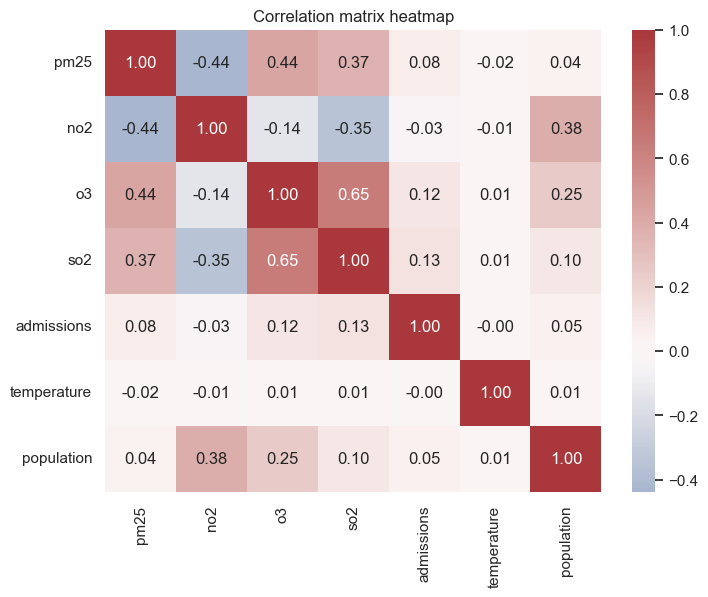

In [46]:
vars_for_corr = pollutants + ["admissions", "temperature", "population"]
corr = df[vars_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix heatmap")
plt.show()

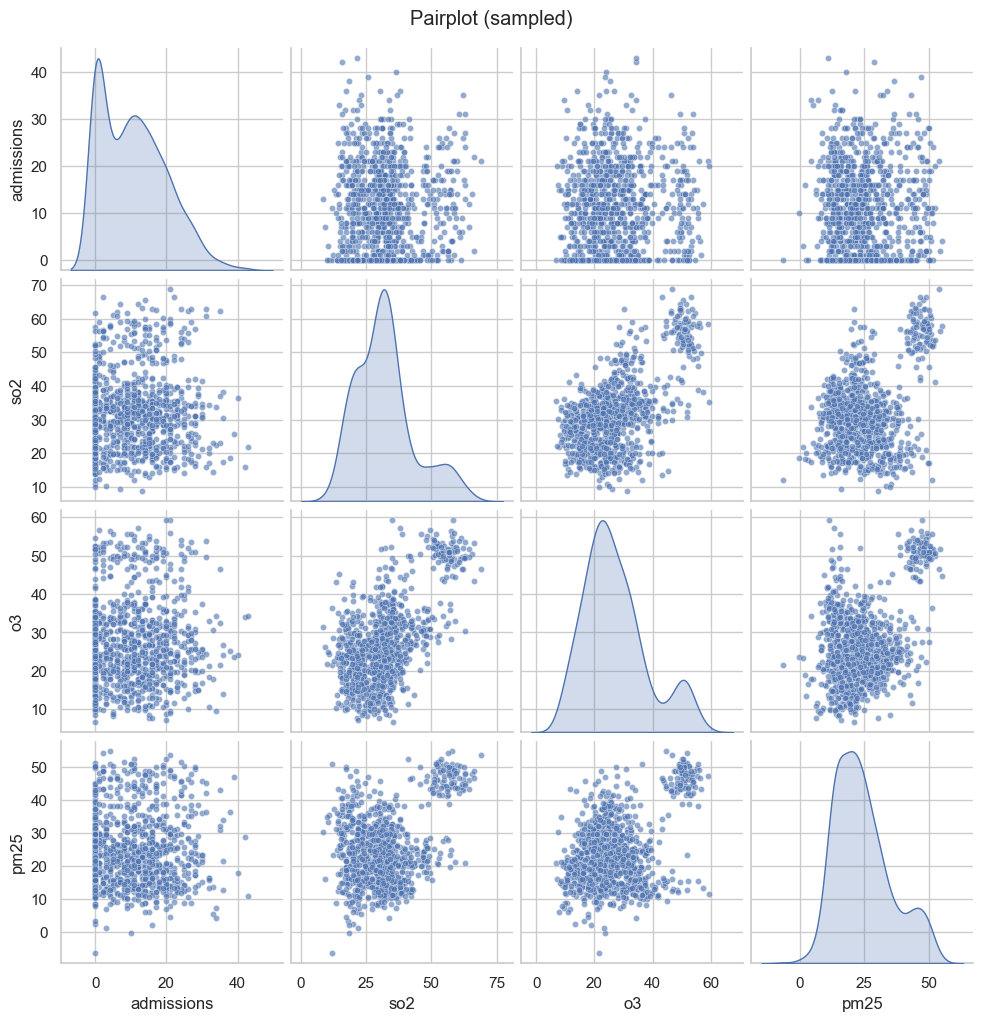

In [47]:
# Use seaborn pairplot with correlations on off-diagonal via a small helper
vars_small = ["admissions", "so2", "o3", "pm25"]
sns.pairplot(df[vars_small].sample(n=1000, random_state=1), diag_kind="kde", plot_kws={"s":20, "alpha":0.6})
plt.suptitle("Pairplot (sampled)", y=1.02)
plt.show()

In [48]:
# Simple OLS (admissions ~ pollutants)
formula = "admissions ~ pm25 + no2 + o3 + so2"
res = smf.ols(formula, data=df).fit()
print(res.summary())

# With city fixed effects (controls for city intercepts)
formula_fe = "admissions ~ pm25 + no2 + o3 + so2 + C(city)"
res_fe = smf.ols(formula_fe, data=df).fit()
print(res_fe.summary())

                            OLS Regression Results                            
Dep. Variable:             admissions   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     18.01
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.18e-14
Time:                        18:33:31   Log-Likelihood:                -13179.
No. Observations:                3650   AIC:                         2.637e+04
Df Residuals:                    3645   BIC:                         2.640e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7266      0.835      6.855      0.0

Explained variance ratio: [0.44164825 0.20048109 0.18497629 0.11697366]


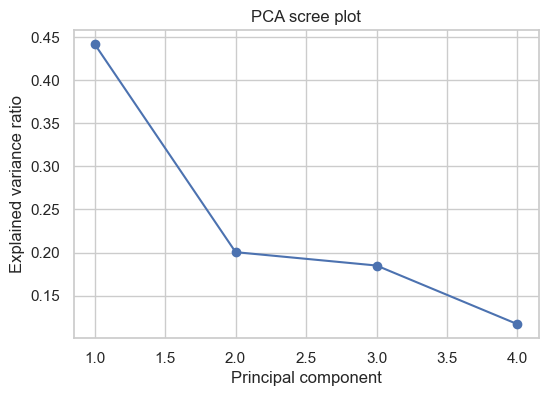

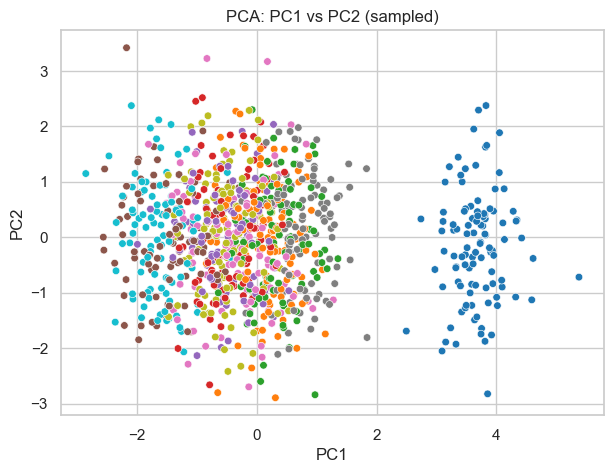

In [49]:
from sklearn.preprocessing import StandardScaler

features = pollutants + ["temperature"]  # choose features for PCA
X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
# Scree plot
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.show()

# Scatter of first two PCs (sample for readability)
sample_idx = np.random.RandomState(0).choice(len(df), size=1000, replace=False)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=pcs[sample_idx, 0], y=pcs[sample_idx, 1], hue=df["city"].iloc[sample_idx], palette="tab10", s=30, legend=False)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 (sampled)")
plt.show()

In [52]:
np.correlate(pcs[:,0], pcs[:,1])

array([8.54150627e-14])

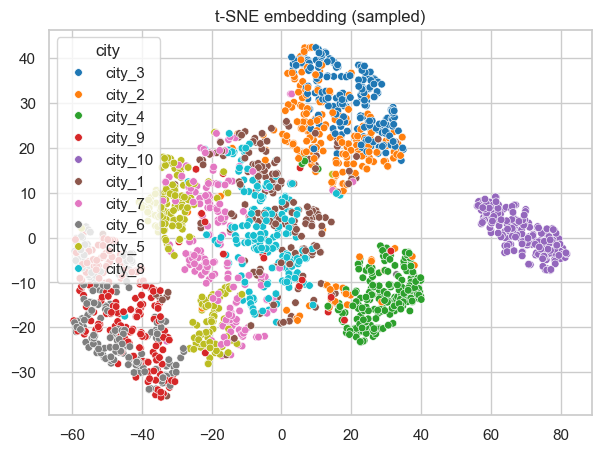

In [54]:
# Use standardized pollutant features (or PCs) and sample for t-SNE
X = StandardScaler().fit_transform(df[pollutants + ["temperature"]].values)
sample_size = 2000
rng = np.random.RandomState(1)
idx = rng.choice(len(X), size=sample_size, replace=False)
X_s = X[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=1, init="pca")
X_emb = tsne.fit_transform(X_s)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=df["city"].iloc[idx], palette="tab10", s=30, legend='full')
plt.title("t-SNE embedding (sampled)")
plt.show()

Decision Tree R^2 (test): -0.09734346813026162


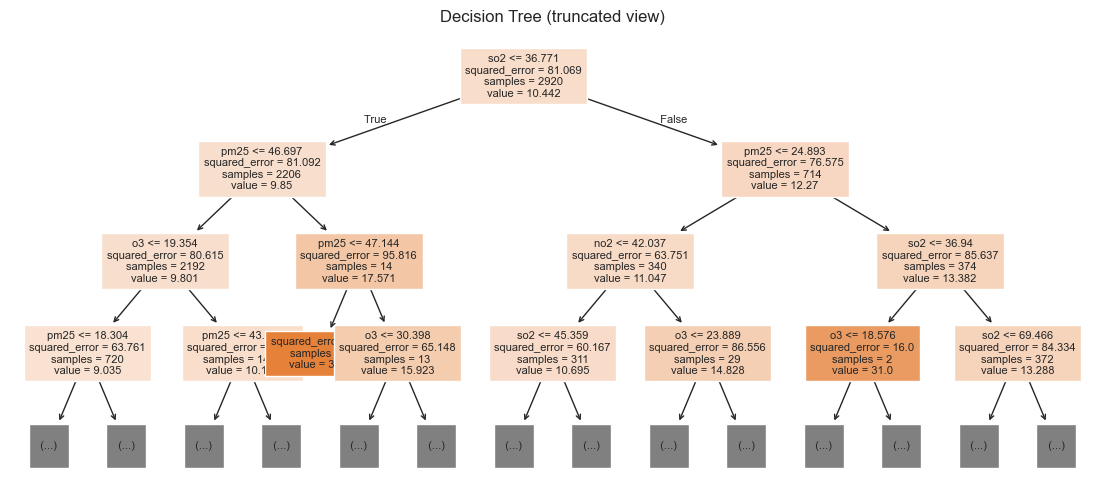

In [62]:
# Train-test split
X = df[pollutants].values
y = df["admissions"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

tree = DecisionTreeRegressor(max_depth=6, random_state=0)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print("Decision Tree R^2 (test):", r2_score(y_test, y_pred))

# Plot the tree (small depth)
plt.figure(figsize=(14, 6))
plot_tree(tree, feature_names=pollutants, filled=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (truncated view)")
plt.show()

In [64]:
bag = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=50, random_state=0, n_jobs=-1)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
print("Bagging R^2 (test):", r2_score(y_test, y_pred_bag))

# Cross-validated score for bagging (negative MSE or R2)
cv_r2 = cross_val_score(bag, X, y, cv=5, scoring="r2", n_jobs=-1)
print("Bagging CV R^2 (5-fold):", cv_r2.mean(), cv_r2)

Bagging R^2 (test): 0.03152602376699287
Bagging CV R^2 (5-fold): -0.024506630533972663 [-0.00796191  0.00354482 -0.02480131 -0.03491517 -0.05839958]


Random Forest R^2 (test): 0.029409879170288145
Feature importances:
 so2     0.305408
pm25    0.272802
o3      0.226148
no2     0.195642
dtype: float64


/var/folders/gf/qd_8fqss2t55m22vdfqdc47m0000gp/T/ipykernel_25050/931380919.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin = df[[top_feat, "admissions"]].groupby(pd.cut(df[top_feat], 30)).mean()


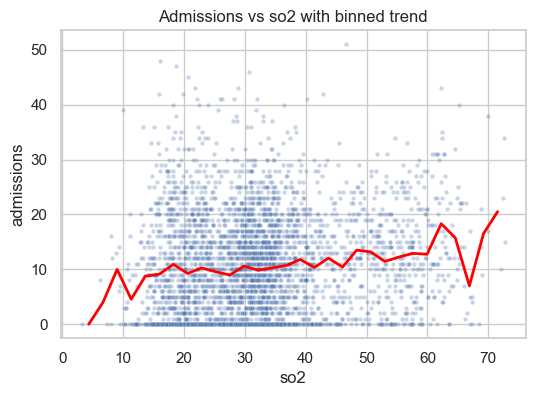

In [65]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R^2 (test):", r2_score(y_test, y_pred_rf))

# Feature importances
importances = pd.Series(rf.feature_importances_, index=pollutants).sort_values(ascending=False)
print("Feature importances:\n", importances)

# Partial dependence-style scatter for top feature
top_feat = importances.index[0]
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df[top_feat], y=df["admissions"], alpha=0.3, s=10)
# show binned mean trend
df_bin = df[[top_feat, "admissions"]].groupby(pd.cut(df[top_feat], 30)).mean()
plt.plot([interval.mid for interval in df_bin.index], df_bin["admissions"], color="red", linewidth=2)
plt.title(f"Admissions vs {top_feat} with binned trend")
plt.show()